# Supplementary Figure 13: sensitivity to the TCN-growth parameterization

Rows a–c use the same growth equations but vary the burden scale $n_c$ and TCN-dependent antibiotic-protection coefficient $\alpha$: (35,40), (20,50), and (15,60). Gain rates are calculated after periodic convergence.

The four effective redistribution pairs $(\kappa_f,\kappa_b)$ in h$^{-1}$ are: −PCN dynamics/−transposition, 0.0075/0.030; −PCN dynamics/+transposition, 0.100/0.120; +PCN dynamics/−transposition, 0.1575/0.130; and +PCN dynamics/+transposition, 0.250/0.220. The +PCN dynamics/−transposition pair applies the same absolute PCN-dynamics increment used in the +transposition background.


In [6]:
%matplotlib inline
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ.setdefault("SIM_RUN_MODE", "production")
%run ./simulation_core.ipynb
plt.rcParams.update(PLOT_STYLE)

OUTPUT_ROOT, FIGURE_DIR, SOURCE_DIR = make_output_dirs("Supplementary_Figure_13_outputs")
PCN_CAPACITY_GRID=(np.array([100],dtype=int) if RUN_MODE=="quick" else np.arange(20,101,5,dtype=int))
PROFILES={"a":GrowthProfile("base",35,40),"b":GrowthProfile("stronger burden/protection",20,50),"c":GrowthProfile("further increased burden/protection",15,60)}
PCN_INC_F=TRANSITIONS.kappa_f_pcn-TRANSITIONS.kappa_f_on
PCN_INC_B=TRANSITIONS.kappa_b_pcn-TRANSITIONS.kappa_b_on
CONDITIONS={
 ("-PCN dynamics","transposition off"):(TRANSITIONS.kappa_f_off,TRANSITIONS.kappa_b_off),
 ("-PCN dynamics","transposition on"):(TRANSITIONS.kappa_f_on,TRANSITIONS.kappa_b_on),
 ("+PCN dynamics","transposition off"):(TRANSITIONS.kappa_f_off+PCN_INC_F,TRANSITIONS.kappa_b_off+PCN_INC_B),
 ("+PCN dynamics","transposition on"):(TRANSITIONS.kappa_f_pcn,TRANSITIONS.kappa_b_pcn),
}


## Converged sensitivity sweep and figure


In [7]:
rows=[]
for panel,profile in PROFILES.items():
    for max_pcn in PCN_CAPACITY_GRID:
        for (pcn_status,condition),(kf,kb) in CONDITIONS.items():
            config=make_configuration(int(max_pcn),condition=condition,kappa_f=kf,kappa_b=kb,setting_label=pcn_status)
            r=evaluate_configuration(int(max_pcn),config,growth_profile=profile)
            r.update({"panel":panel,"pcn_dynamics":pcn_status,"burden_scale":profile.burden_scale,"alpha":profile.protection_alpha})
            rows.append(r)
results=pd.DataFrame(rows)



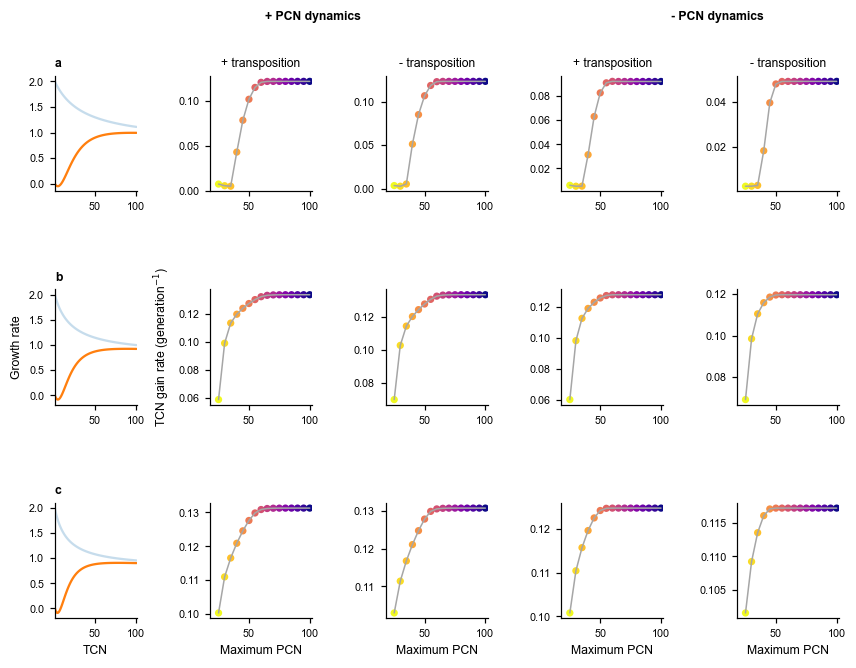

In [9]:
column_specs=[("+PCN dynamics","transposition on"),("+PCN dynamics","transposition off"),
              ("-PCN dynamics","transposition on"),("-PCN dynamics","transposition off")]
fig=plt.figure(figsize=(9.2,6.4)); gs=fig.add_gridspec(3,5,width_ratios=[0.8,1,1,1,1],wspace=0.75,hspace=0.85)
for r,(panel,profile) in enumerate(PROFILES.items()):
    ax=fig.add_subplot(gs[r,0]); x=total_tcn_states(100)
    ax.plot(x,growth_rates(100,selected=False,growth_profile=profile),alpha=0.25)
    ax.plot(x,growth_rates(100,selected=True,growth_profile=profile))
    ax.set_title(panel,loc="left",fontweight="bold"); ax.set_xlim(1,101)
    if r==2: ax.set_xlabel("TCN")
    if r==1: ax.set_ylabel("Growth rate")
    for c,(pcn_status,condition) in enumerate(column_specs):
        a=fig.add_subplot(gs[r,c+1])
        d=results[(results.panel==panel)&(results.pcn_dynamics==pcn_status)&(results.condition==condition)&results.response_valid].sort_values("maximum_PCN")
        a.scatter(d.maximum_PCN,d.gain_rate,c=d.maximum_PCN,cmap="plasma_r",s=14)
        a.plot(d.maximum_PCN,d.gain_rate,color="0.65",lw=1)
        a.set_xlim(18,102)
        if r==2: a.set_xlabel("Maximum PCN")
        if c==0 and r==1: a.set_ylabel("TCN gain rate (generation$^{-1}$)")
        if r==0: a.set_title("+ transposition" if condition=="transposition on" else "- transposition")
fig.text(0.38,0.96,"+ PCN dynamics",ha="center",fontweight="bold")
fig.text(0.78,0.96,"- PCN dynamics",ha="center",fontweight="bold")
save_figure(fig,"Supplementary_Figure_13_growth_sensitivity",FIGURE_DIR); plt.show()

export_table(results,"Supplementary_Figure_13_source_data.csv",SOURCE_DIR)
export_table(core_metadata("Supplementary Figure 13"),"Supplementary_Figure_13_run_metadata.csv",SOURCE_DIR)
